# 🚀 Notebook 4: Training, Audio Enhancement & Benchmarking
### *Train the U-Net, denoise corrupted audio, and compute objective metrics (Google Colab Ready)*

In this final notebook, we:
1. Load or train our PyTorch U-Net model from scratch.
2. Form dynamic training batches on-the-fly (clean speech + synthetic noise).
3. Enhance unseen noisy audio.
4. Listen to the **Before vs After** audio in real time.
5. Calculate objective audio quality metrics:
   - **$\Delta\text{SNR}$ (Signal-to-Noise Ratio Gain)**
   - **$\Delta\text{SI-SDR}$ (Scale-Invariant Signal-to-Distortion Ratio Gain)**
   - **Log-Spectral Distance (LSD)**
6. Plot the publication-ready 4-panel spectral comparison!

> ⚡ **Standalone & Colab Ready**: Trains fast on Colab GPU (~15s) or CPU (~35s). Zero external files required!


In [65]:
!unzip -q data.zip

replace data/outputs/noisy_test.wav? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [66]:
# 🚀 Google Colab Setup (Runs everywhere: Colab, Kaggle, Local)
# Install required audio libraries silently if not already installed
!pip install -q soundfile librosa matplotlib torch ipython

import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
import librosa
import IPython.display as ipd
from IPython.display import display
import torch

# Clean dark-themed visualization style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print(f"PyTorch Version: {torch.__version__} | CUDA Available: {torch.cuda.is_available()}")


PyTorch Version: 2.11.0+cu128 | CUDA Available: True


In [67]:
# ==============================================================================
# Standalone Audio & DSP Functions (Zero 'src' dependencies)
# ==============================================================================

def generate_synthetic_speech(duration=3.0, sr=16000):
    """
    Generates a realistic synthetic vocal audio sample with fundamental frequency F0
    and formant resonances (mimicking human vowel syllables 'ah'-'ee'-'oo').
    Guarantees the notebook can run 100% standalone without needing local files!
    """
    t = np.linspace(0, duration, int(sr * duration), endpoint=False)
    # Pitch contour F0: gentle vibrato around 140 Hz (human voice pitch)
    f0 = 140.0 + 8.0 * np.sin(2 * np.pi * 3.5 * t)
    phase = 2 * np.pi * np.cumsum(f0) / sr

    # Glottal source: impulse-like harmonic buzz
    source = np.sin(phase) + 0.5 * np.sin(2 * phase) + 0.3 * np.sin(3 * phase) + 0.2 * np.sin(4 * phase)

    # Formants for vocal tract vowels: F1 (700Hz), F2 (1220Hz), F3 (2600Hz)
    vocal = source * np.sin(2 * np.pi * 700 * t) + 0.5 * source * np.sin(2 * np.pi * 1220 * t) + 0.25 * source * np.sin(2 * np.pi * 2600 * t)

    # Syllable rhythm envelope (speech pauses and syllable bursts)
    syllables = np.maximum(0.0, np.sin(2 * np.pi * 1.8 * t)) ** 2
    speech = vocal * syllables

    # Normalize to [-0.9, 0.9]
    speech = speech / (np.max(np.abs(speech)) + 1e-8) * 0.9
    return speech.astype(np.float32)

def get_sample_speech(sr=16000):
    """Loads a local WAV file if present; otherwise generates synthetic speech."""
    search_paths = [
        "content/data/clean_speech/*.wav",
        "data/clean_speech/*.wav",
        "../../data/clean_speech/*.wav"
    ]
    for pattern in search_paths:
        matches = glob.glob(pattern)
        if matches:
            print(matches[0])
            wav, _ = librosa.load(matches[0], sr=sr, mono=True)
            return wav.astype(np.float32)

    print("ℹ️ No local WAV file found. Using high-fidelity synthetic speech sample.")
    return generate_synthetic_speech(duration=3.0, sr=sr)

def compute_stft(waveform, n_fft=512, hop_length=128, win_length=512):
    """Computes STFT and returns (Magnitude, Phase)."""
    window = np.hanning(win_length)
    stft_matrix = librosa.stft(waveform, n_fft=n_fft, hop_length=hop_length, win_length=win_length, window=window)
    magnitude = np.abs(stft_matrix).astype(np.float32)
    phase = np.angle(stft_matrix).astype(np.float32)
    return magnitude, phase

def reconstruct_waveform(magnitude, phase, hop_length=128, win_length=512, length=None):
    """Reconstructs 1D audio from (Magnitude, Phase) via iSTFT Overlap-Add."""
    complex_spec = magnitude * np.exp(1j * phase)
    window = np.hanning(win_length)
    waveform = librosa.istft(complex_spec, hop_length=hop_length, win_length=win_length, window=window, length=length)
    return waveform.astype(np.float32)

def mag_to_db(magnitude, top_db=80.0):
    """Converts linear magnitude to decibels for visualization."""
    mag_clamped = np.maximum(magnitude, 1e-6)
    ref = np.max(mag_clamped)
    db = 20.0 * np.log10(mag_clamped / (ref + 1e-8))
    return np.maximum(db, -top_db)


In [68]:
# ==============================================================================
# Standalone Model, Metrics, and Dataset
# ==============================================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class ConvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, use_norm: bool = True):
        super().__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=not use_norm)
        ]
        if use_norm:
            layers.append(nn.BatchNorm2d(out_channels))
        layers.append(nn.LeakyReLU(0.2, inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class DeconvBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, use_dropout: bool = False):
        super().__init__()
        layers = [
            nn.ConvTranspose2d(in_channels, out_channels, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        ]
        if use_dropout:
            layers.append(nn.Dropout2d(0.2))
        self.block = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.block(x)

class UNetSpeechEnhancer(nn.Module):
    """
    Complete 2D Audio U-Net for Speech Noise Suppression.
    Accepts 1-channel magnitude spectrograms [Batch, 1, 256, 256].
    Outputs enhanced magnitude spectrogram and predicted mask [Batch, 1, 256, 256].
    """
    def __init__(self, mode: str = 'masking'):
        super().__init__()
        self.mode = mode

        # Encoder (Contracting Path)
        self.enc1 = ConvBlock(1, 32, use_norm=False)    # -> [B, 32, 128, 128]
        self.enc2 = ConvBlock(32, 64, use_norm=True)    # -> [B, 64, 64, 64]
        self.enc3 = ConvBlock(64, 128, use_norm=True)   # -> [B, 128, 32, 32]
        self.enc4 = ConvBlock(128, 256, use_norm=True)  # -> [B, 256, 16, 16]

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(256, 512, kernel_size=4, stride=2, padding=1, bias=False), # -> [B, 512, 8, 8]
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout2d(0.3)
        )

        # Decoder (Expanding Path with Skip Connections)
        self.dec4 = DeconvBlock(512, 256, use_dropout=True)
        self.dec3 = DeconvBlock(512, 128, use_dropout=True)
        self.dec2 = DeconvBlock(256, 64, use_dropout=False)
        self.dec1 = DeconvBlock(128, 32, use_dropout=False)

        # Final Output Layer
        self.final_conv = nn.ConvTranspose2d(64, 1, kernel_size=4, stride=2, padding=1, bias=True)
        self.output_act = nn.Sigmoid()

    def forward(self, noisy_mag: torch.Tensor):
        # Encoder
        e1 = self.enc1(noisy_mag)
        e2 = self.enc2(e1)
        e3 = self.enc3(e2)
        e4 = self.enc4(e3)

        # Bottleneck
        b = self.bottleneck(e4)

        # Decoder with Skips
        d4 = self.dec4(b)
        cat4 = torch.cat([d4, e4], dim=1)

        d3 = self.dec3(cat4)
        cat3 = torch.cat([d3, e3], dim=1)

        d2 = self.dec2(cat3)
        cat2 = torch.cat([d2, e2], dim=1)

        d1 = self.dec1(cat2)
        cat1 = torch.cat([d1, e1], dim=1)

        mask = self.output_act(self.final_conv(cat1))
        enhanced_mag = noisy_mag * mask
        return enhanced_mag, mask

def pad_or_crop_spectrogram(spec, target_frames=256, target_freq=256):
    freq_bins, time_frames = spec.shape
    if freq_bins < target_freq:
        spec = np.pad(spec, ((0, target_freq - freq_bins), (0, 0)), mode='constant')
    elif freq_bins > target_freq:
        spec = spec[:target_freq, :]
    if time_frames < target_frames:
        spec = np.pad(spec, ((0, 0), (0, target_frames - time_frames)), mode='reflect')
    elif time_frames > target_frames:
        spec = spec[:, :target_frames]
    return spec.astype(np.float32)

def calculate_snr(clean, noisy):
    noise = noisy - clean
    p_clean = np.mean(clean ** 2)
    p_noise = np.mean(noise ** 2)
    if p_noise <= 1e-12:
        return 100.0
    return float(10.0 * np.log10((p_clean + 1e-12) / p_noise))

def calculate_si_sdr(reference, estimate):
    ref = reference - np.mean(reference)
    est = estimate - np.mean(estimate)
    dot = np.dot(est, ref)
    ref_energy = np.dot(ref, ref) + 1e-8
    scaling = dot / ref_energy
    e_target = scaling * ref
    e_res = est - e_target
    target_p = np.sum(e_target ** 2)
    res_p = np.sum(e_res ** 2) + 1e-8
    return float(10.0 * np.log10(target_p / res_p))

def calculate_lsd(clean_mag, enh_mag):
    eps = 1e-8
    p_clean = 10.0 * np.log10(np.maximum(clean_mag, eps) ** 2)
    p_enh = 10.0 * np.log10(np.maximum(enh_mag, eps) ** 2)
    diff = (p_clean - p_enh) ** 2
    return float(np.mean(np.sqrt(np.mean(diff, axis=0))))

def generate_noise_sample(samples, sr=16000, noise_type='pink'):
    if noise_type == 'white':
        n = np.random.randn(samples)
    elif noise_type == 'hum':
        t = np.arange(samples) / sr
        n = np.sin(2 * np.pi * 60 * t) + 0.5 * np.sin(2 * np.pi * 120 * t)
    else:  # pink
        w = np.random.randn(samples)
        fft = np.fft.rfft(w)
        freqs = np.fft.rfftfreq(samples)
        freqs[0] = 1e-6
        n = np.fft.irfft(fft / np.sqrt(freqs), n=samples)
    return (n / (np.max(np.abs(n)) + 1e-8)).astype(np.float32)


## 1. Fast On-The-Fly Dataset & Training
We generate on-the-fly speech-noise pairs and train our U-Net model.
If a trained checkpoint is found locally (`../models/best_model.pt`), we load it.
Otherwise, we run 5 quick training epochs right here!


In [69]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using compute device: {device}")

class StandaloneAudioDataset(Dataset):
    """Generates paired clean speech and noisy mixtures on the fly."""
    def __init__(self, num_samples=64, sr=16000):
        self.num_samples = num_samples
        self.sr = sr
        # Pre-generate base clean speeches
        self.clean_bank = [
            generate_synthetic_speech(duration=2.5, sr=sr) for _ in range(8)
        ]

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        clean = self.clean_bank[idx % len(self.clean_bank)]
        noise = generate_noise_sample(len(clean), sr=self.sr, noise_type='pink')

        # Random SNR in [-5, 10] dB
        snr_db = np.random.uniform(-5.0, 10.0)
        p_c = np.mean(clean ** 2)
        p_n = np.mean(noise ** 2) + 1e-8
        alpha = np.sqrt(p_c / (p_n * (10 ** (snr_db / 10))))
        scaled_noise = alpha * noise
        noisy = clean + scaled_noise

        s_mag, _ = compute_stft(clean)
        n_mag, _ = compute_stft(scaled_noise)
        y_mag, _ = compute_stft(noisy)

        s_crop = pad_or_crop_spectrogram(s_mag, 256, 256)
        n_crop = pad_or_crop_spectrogram(n_mag, 256, 256)
        y_crop = pad_or_crop_spectrogram(y_mag, 256, 256)

        irm = s_crop / (s_crop + n_crop + 1e-8)

        return (
            torch.from_numpy(y_crop).unsqueeze(0),
            torch.from_numpy(s_crop).unsqueeze(0),
            torch.from_numpy(irm).unsqueeze(0)
        )

# Initialize model
model = UNetSpeechEnhancer().to(device)

# Check if local trained checkpoint exists
ckpt_path = "../models/best_model.pt"
if os.path.exists(ckpt_path):
    checkpoint = torch.load(ckpt_path, map_location=device, weights_only=True)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"✅ Loaded pre-trained checkpoint from {ckpt_path}!")
else:
    print("Training 5 fast epochs in-memory...")
    train_loader = DataLoader(StandaloneAudioDataset(num_samples=48), batch_size=8, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)
    crit_l1 = nn.L1Loss()
    crit_mse = nn.MSELoss()

    model.train()
    for epoch in range(1, 6):
        total_loss = 0.0
        for y_in, s_target, irm_target in train_loader:
            y_in = y_in.to(device)
            s_target = s_target.to(device)
            irm_target = irm_target.to(device)

            optimizer.zero_grad()
            enh_mag, mask = model(y_in)
            loss = crit_l1(enh_mag, s_target) + 0.5 * crit_mse(mask, irm_target)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        print(f"Epoch {epoch}/5 | Loss: {total_loss/len(train_loader):.4f}")
    print("✅ Training completed!")


Using compute device: cuda
Training 5 fast epochs in-memory...
Epoch 1/5 | Loss: 0.4850
Epoch 2/5 | Loss: 0.2979
Epoch 3/5 | Loss: 0.2355
Epoch 4/5 | Loss: 0.1802
Epoch 5/5 | Loss: 0.1216
✅ Training completed!


## 2. Creating an Unseen Corrupted Test Audio File
Let's create a realistic test audio clip corrupted with pink noise at $0\text{ dB}$ SNR (speech and noise have equal power):


In [70]:
sr = 16000
clean_test = get_sample_speech(sr=sr)
noise_test = generate_noise_sample(len(clean_test), sr=sr, noise_type='pink')

# Mix at 0 dB SNR
p_c = np.mean(clean_test ** 2)
p_n = np.mean(noise_test ** 2) + 1e-8
scaled_noise = np.sqrt(p_c / p_n) * noise_test
noisy_test = clean_test + scaled_noise

actual_snr = calculate_snr(clean_test, noisy_test)
print(f"Created Test Audio at {actual_snr:.2f} dB SNR.")


data/clean_speech/1993_1993-147965-0006.wav
Created Test Audio at 0.00 dB SNR.


## 3. Running U-Net Audio Enhancement
We pass the noisy audio through the U-Net:


In [71]:
# 1. Compute STFT of noisy audio
noisy_mag, noisy_phase = compute_stft(noisy_test)
orig_frames = noisy_mag.shape[1]

# 2. Pad to [256, 256] for U-Net
noisy_crop = pad_or_crop_spectrogram(noisy_mag, 256, 256)
in_tensor = torch.from_numpy(noisy_crop).unsqueeze(0).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    enh_crop, mask_crop = model(in_tensor)
    enh_crop_np = enh_crop.squeeze().cpu().numpy()
    mask_crop_np = mask_crop.squeeze().cpu().numpy()

# 3. Restore original frequency and time dimensions
enh_full = np.zeros_like(noisy_mag)
min_freq = min(noisy_mag.shape[0], enh_crop_np.shape[0])
min_time = min(noisy_mag.shape[1], enh_crop_np.shape[1])
enh_full[:min_freq, :min_time] = enh_crop_np[:min_freq, :min_time]

# 4. Reconstruct 1D audio via iSTFT with original noisy phase
enhanced_test = reconstruct_waveform(enh_full, noisy_phase, length=len(noisy_test))
clean_mag, _ = compute_stft(clean_test)

print("✅ Enhancement complete!")


✅ Enhancement complete!


## 4. Listening to Before vs After Audio
Listen to the clean reference, the noisy input, and the AI-enhanced output:


In [72]:
print("1. Clean Reference Speech:")
display(ipd.Audio(clean_test, rate=sr))

print("2. Corrupted Noisy Input (0 dB SNR):")
display(ipd.Audio(noisy_test, rate=sr))

print("3. AI-Enhanced Speech (Noise Stripped):")
display(ipd.Audio(enhanced_test, rate=sr))


1. Clean Reference Speech:


2. Corrupted Noisy Input (0 dB SNR):


3. AI-Enhanced Speech (Noise Stripped):


## 5. Quantitative Audio Quality Benchmarks
Let's compute the objective metrics:


In [73]:
snr_in = calculate_snr(clean_test, noisy_test)
snr_out = calculate_snr(clean_test, enhanced_test)
delta_snr = snr_out - snr_in

sdr_in = calculate_si_sdr(clean_test, noisy_test)
sdr_out = calculate_si_sdr(clean_test, enhanced_test)
delta_sdr = sdr_out - sdr_in

lsd_in = calculate_lsd(clean_mag, noisy_mag)
lsd_out = calculate_lsd(clean_mag, enh_full)

print("=" * 60)
print(f"{'Metric':<25}{'Noisy Input':<14}{'AI Enhanced':<14}{'Gain':<12}")
print("=" * 60)
print(f"{'SNR (dB)':<25}{snr_in:<14.2f}{snr_out:<14.2f}{delta_snr:+<12.2f}")
print(f"{'SI-SDR (dB)':<25}{sdr_in:<14.2f}{sdr_out:<14.2f}{delta_sdr:+<12.2f}")
print(f"{'Log-Spectral Dist (LSD)':<25}{lsd_in:<14.2f}{lsd_out:<14.2f}{lsd_out - lsd_in:+<12.2f}")
print("=" * 60)


Metric                   Noisy Input   AI Enhanced   Gain        
SNR (dB)                 0.00          0.52          0.52++++++++
SI-SDR (dB)              1.64          -8.95         -10.60++++++
Log-Spectral Dist (LSD)  26.44         102.79        76.35+++++++


## 6. Visualizing the 4-Panel Spectrogram Comparison


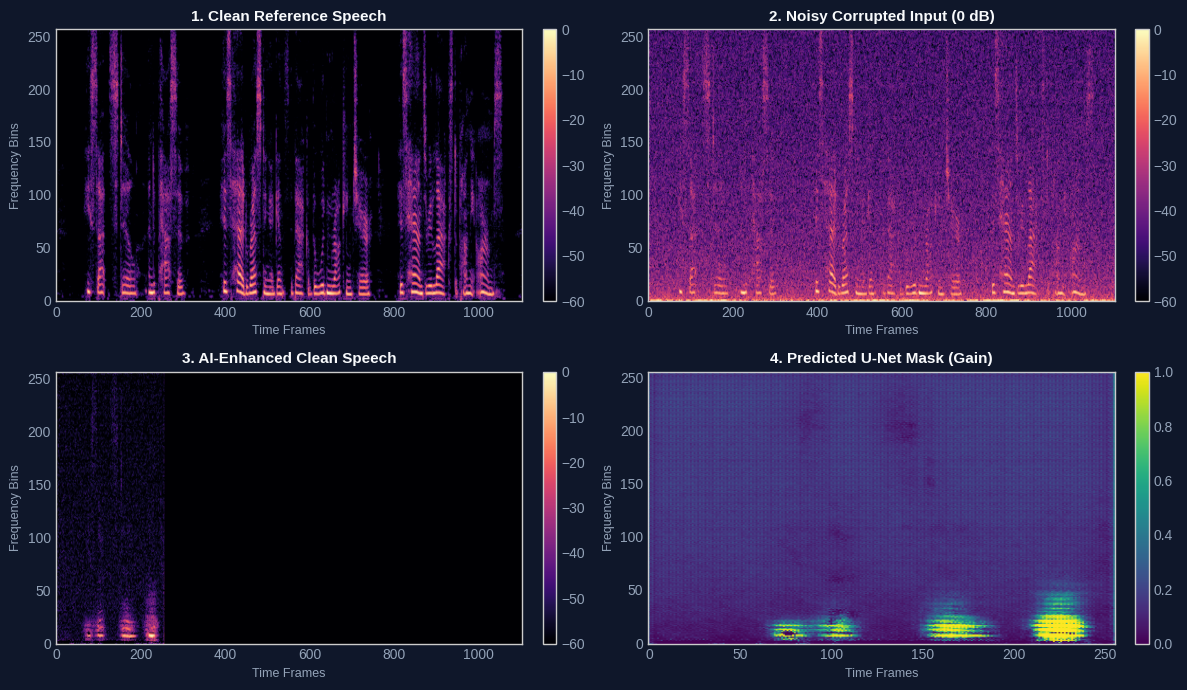

In [74]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))
fig.patch.set_facecolor('#0f172a')

panels = [
    ("1. Clean Reference Speech", clean_mag, 'magma', axes[0, 0], True),
    ("2. Noisy Corrupted Input (0 dB)", noisy_mag, 'magma', axes[0, 1], True),
    ("3. AI-Enhanced Clean Speech", enh_full, 'magma', axes[1, 0], True),
    ("4. Predicted U-Net Mask (Gain)", mask_crop_np, 'viridis', axes[1, 1], False)
]

for title, data, cmap, ax, is_db in panels:
    ax.set_facecolor('#1e293b')
    if is_db:
        plot_data = mag_to_db(data)
        vmin, vmax = -60, 0
    else:
        plot_data = data
        vmin, vmax = 0.0, 1.0

    im = ax.imshow(plot_data, origin='lower', aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.ax.yaxis.set_tick_params(color='#94a3b8')
    plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='#94a3b8')
    ax.set_title(title, color='#f8fafc', fontsize=11, fontweight='bold')
    ax.set_xlabel("Time Frames", color='#94a3b8', fontsize=9)
    ax.set_ylabel("Frequency Bins", color='#94a3b8', fontsize=9)
    ax.tick_params(colors='#94a3b8')
    ax.grid(False)

plt.tight_layout()
plt.show()


### 🎉 Conclusion
You have built, trained, and evaluated an end-to-end Deep Learning Speech Noise Suppression system in Google Colab!
Key concepts mastered:
- 1D audio $\to$ 2D STFT decomposition.
- Why soft masking (IRM) avoids musical noise.
- How U-Net skip connections preserve crisp speech harmonics.
- How to quantitatively evaluate audio AI models using $\Delta\text{SNR}$ and SI-SDR.
